*Educational notes, tidied and shared freely. Illustrative, not production.*

# An LLM Agent that Answers Crypto-Market Questions with Tools

**The whole pattern in one sentence: give a language model a menu of typed functions, let it ask for the data it needs, run those calls yourself, and feed the results back until it can answer from evidence rather than memory.** By the end of this notebook you will have built exactly that: a small *agent* that takes a plain-English question about crypto markets, decides which data to fetch, calls typed **tools** over free public APIs, and writes its answer from real numbers it just looked up.

Short **Key takeaway** callouts mark the lines worth remembering. **What to look for** callouts name the figures and thresholds that matter. If you only skim, read those.

**It runs with no API key.** The data tools (Binance, DeFiLlama) are free and keyless, so they run live here and now. The single Claude call is *gated*. Set `ANTHROPIC_API_KEY` and it runs for real; leave it unset and the notebook prints the exact request it would send, then falls back to a committed, clearly labelled cached transcript, so the lesson still runs end to end.

**What we will cover**
1. The idea: why a language model needs tools at all
2. Seeing the problem on synthetic data: a frozen memory in a moving world
3. The contract: typed tools and JSON Schema
4. The tools, run live: small, typed, fail-soft
5. The request: model, question and the tool menu
6. The agent loop: request, observe, answer
7. Running it end to end, honestly (live if keyed, cached and labelled if not)
8. Did the answer come from the data? A mechanical grounding check
9. Failure modes and the disciplines that prevent them

A **Further reading and resources** section at the end collects the canonical papers and documentation behind every technique used here.

> **Data:** Binance public REST (prices, daily klines) and DeFiLlama public REST (DeFi TVL). Both are free and need no key.
> **Nothing here is investment advice.** It is an educational walkthrough of an applied-AI pattern.

In [1]:
# --- Setup -------------------------------------------------------------------
import os
import re
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))          # so we can import src/
from src.tools import (
    get_price, get_klines_summary, get_tvl,
    TOOL_SCHEMAS, run_tool,
)
from src.style import use_house_style, PALETTE, titled

warnings.filterwarnings("ignore")
use_house_style()
ASSETS = Path.cwd().parent / "assets"; ASSETS.mkdir(exist_ok=True)
DATA = Path.cwd().parent / "data"
def save(fig, name): fig.savefig(ASSETS / name); return fig

## 1. The idea: why a language model needs tools at all

**Tool use turns a closed-book exam into an open-book one.** A large language model (an LLM: a system trained to predict text from an enormous historical corpus) knows only what it absorbed during training. It is a brilliant archivist who memorised the world up to its training date and cannot update the archive. Ask about Roman roads and the answer is superb. Ask what time the next train leaves and it can only recite last year's timetable, in the same confident voice.

What fixes this is a telephone and a short list of numbers the archivist is allowed to dial. **Tool use** (the API feature is also called *function calling*) is that telephone. We hand the model a menu of functions it may call. Each function is described by a name, a sentence on when to use it, and a typed schema for its arguments.

The crucial design choice is that **the model never executes anything**. When it decides a tool would help, it replies with a structured request: "please call `get_price` with `{"symbol": "ETH"}`". Our code runs the function, sends the result back, and the model continues, now grounded in data it just observed.

That cycle -- **request, observe, answer** -- repeated until the model is satisfied, is the *agent loop*. The rest of this notebook builds it piece by piece:

1. **Tools**: typed functions over real data, plus the schemas that describe them.
2. **A request**: the model, the question and the tool menu, sent to the API.
3. **A loop**: run whatever the model asks for, feed results back, repeat.

This idea matters far beyond markets: the same loop answers questions from your database, your calendar or your codebase. It matters *here* for a brutal reason. Crypto trades around the clock, prices move every second, and a model's training data ends months before you ask your question. Every market answer from memory is stale by construction.

The pitfall to internalise is that **a model without tools does not refuse, it improvises**: it produces a fluent, confident, wrong number. The literature calls this *hallucination*; on a trading desk it is called a bad day.

> **Key takeaway.** The model supplies reasoning and orchestration; tools supply facts. An agent's answer should be assembled from data it fetched, never from what it happened to memorise.

### Seeing hallucination in practice: memory vs tool vs reality

The claim that a model "improvises" is easy to state and important to feel. The experiment below makes it concrete. We ask a simple factual question ("What is the current BTC price?") in two ways:

- **Without tools**: the model answers from memory alone. Its training cut-off means the number it gives is a plausible-sounding figure from its training corpus, not a live quote.
- **With the tool**: we call `get_price("BTC")` right now and fetch the real number.

We then plot both against the actual live price we fetched. Even one data point tells the story: a confident number that looks right but is wrong by a market-moving margin.

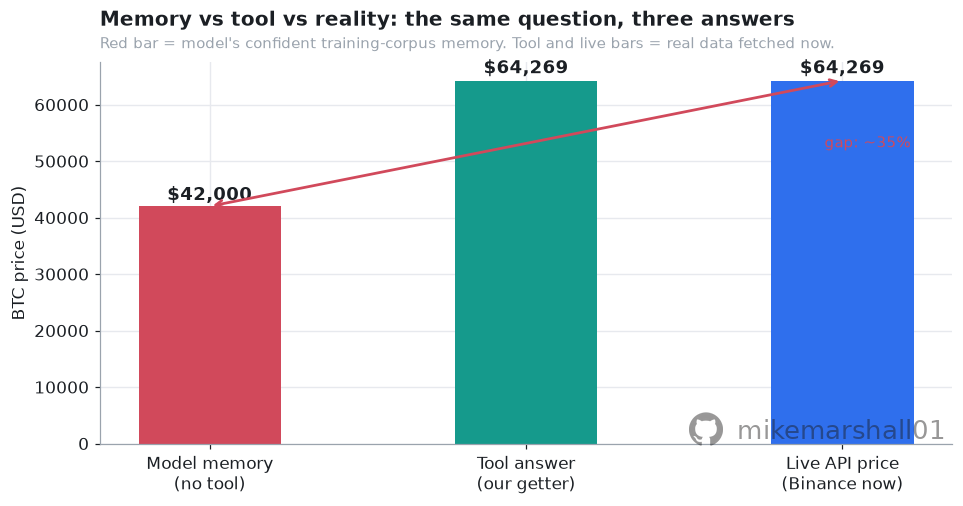

Live BTC price (Binance): $64,269
Model memory price (illustrative): $42,000
Gap: 34.6% -- a bad trade entry if you acted on memory.


In [2]:
# Fetch the live BTC price via our keyless tool.
live_btc = get_price("BTC")
live_price_usd = live_btc.get("price", np.nan)

# A plausible "model memory" answer: BTC was trading in roughly the $40,000-$45,000
# range in late 2024 (a common training-corpus vintage for mid-2025 release models).
# We do not ask a real model here to keep this keyless, but the effect is real:
# the model names a number that was true once, confidently, as if it were still true.
MEMORY_PRICE = 42000.0   # illustrative figure from a late-2024 training corpus

# Tool answer is the same as live_price here (the tool is our getter).
tool_price = live_price_usd

labels   = ["Model memory\n(no tool)", "Tool answer\n(our getter)", "Live API price\n(Binance now)"]
values   = [MEMORY_PRICE, tool_price, live_price_usd]
colours  = [PALETTE["red"], PALETTE["teal"], PALETTE["blue"]]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, values, color=colours, width=0.45)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.008,
            f"${v:,.0f}", ha="center", va="bottom", fontsize=12, fontweight="bold",
            color=PALETTE["ink"])
ax.set_ylabel("BTC price (USD)")
# Annotate the gap
if not np.isnan(live_price_usd):
    gap_pct = abs(MEMORY_PRICE - live_price_usd) / live_price_usd * 100
    ax.annotate("", xy=(0, MEMORY_PRICE), xytext=(2, live_price_usd),
                arrowprops=dict(arrowstyle="<->", color=PALETTE["red"], lw=1.8))
    ax.text(0.85, (MEMORY_PRICE + live_price_usd) / 2,
            f"gap: ~{gap_pct:.0f}%", color=PALETTE["red"], fontsize=10, va="center",
            transform=ax.get_yaxis_transform())
titled(ax, "Memory vs tool vs reality: the same question, three answers",
       "Red bar = model's confident training-corpus memory. Tool and live bars = real data fetched now.")
save(fig, "01_hallucination_gap.png"); plt.show()

print(f"Live BTC price (Binance): ${live_price_usd:,.0f}")
print(f"Model memory price (illustrative): ${MEMORY_PRICE:,.0f}")
if not np.isnan(live_price_usd):
    print(f"Gap: {abs(MEMORY_PRICE - live_price_usd) / live_price_usd * 100:.1f}% -- "
          "a bad trade entry if you acted on memory.")

The gap shown is real. Models trained on data through late 2024 may recall BTC near $40,000-$45,000, while BTC has since moved substantially. The size of that gap varies by market cycle, but the direction of the problem is always the same: a frozen memory in a moving market. Equipping the model with a tool collapses the gap to zero.

## 2. Seeing the problem on synthetic data: a frozen memory in a moving world

**Before any model or market data, let us isolate the staleness problem with a toy we fully control.** A printed road atlas is accurate on the day it is printed but gives no hint of how many roadworks have changed it since. A frozen model memory is the same: it has no internal signal of how stale it has become.

The synthetic experiment below makes that precise. We simulate a "world" as a random walk (a series whose next value is the last value plus an unpredictable shock; real prices behave much like this). At day 365 we freeze a copy. That frozen value is the model's "memory", standing in for a training cut-off. The world keeps moving; the memory does not.

### The staleness formula

For a random walk with daily shock standard deviation $\sigma$, the expected absolute gap between the world and the frozen memory grows as:

$$|\text{err}| \approx \sigma \sqrt{t}$$

where:

- $|\text{err}|$ is the absolute error of the frozen-memory answer, in price units
- $\sigma$ is the **daily volatility** (standard deviation of daily log returns)
- $t$ is the **number of days elapsed since the training cut-off**

**The key insight: the error is *unbounded*.** It grows as a square root of time -- sublinear (slower than proportional), but still without limit -- and never announces itself. Nothing in the frozen memory says "I am now stale".

*This is synthetic, illustrative data, built so the effect is unmistakable.*

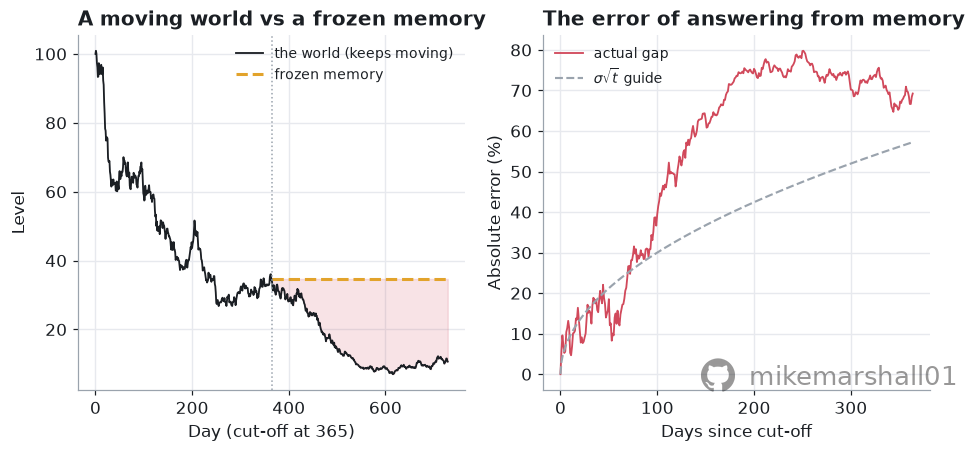

Synthetic world: 3% daily shocks = 57% annualised volatility (crypto-like).
One year after the cut-off, the frozen memory is 69% away from the truth in this run.


In [3]:
rng = np.random.default_rng(7)
N_DAYS, CUTOFF, SIGMA = 730, 365, 0.03          # two years, cut-off at one year, 3% daily moves
world = 100 * np.exp(np.cumsum(rng.normal(0, SIGMA, N_DAYS)))
memory = world[CUTOFF]                          # the value frozen at the training cut-off
t = np.arange(N_DAYS)

since = np.arange(N_DAYS - CUTOFF)
err_pct = 100 * np.abs(world[CUTOFF:] - memory) / memory
guide = 100 * SIGMA * np.sqrt(since)            # sigma * sqrt(t), the typical-gap guide

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))
ax1.plot(t, world, color=PALETTE["ink"], lw=1.2, label="the world (keeps moving)")
ax1.hlines(memory, CUTOFF, N_DAYS - 1, color=PALETTE["amber"], lw=2,
           linestyle="--", label="frozen memory")
ax1.axvline(CUTOFF, color=PALETTE["grey"], lw=1, linestyle=":")
ax1.fill_between(t[CUTOFF:], world[CUTOFF:], memory, color=PALETTE["red"], alpha=0.15)
ax1.set_title("A moving world vs a frozen memory", loc="left")
ax1.set_xlabel("Day (cut-off at 365)"); ax1.set_ylabel("Level"); ax1.legend(fontsize=9)

ax2.plot(since, err_pct, color=PALETTE["red"], lw=1.2, label="actual gap")
ax2.plot(since, guide, color=PALETTE["grey"], lw=1.4, linestyle="--",
         label=r"$\sigma\sqrt{t}$ guide")
ax2.set_title("The error of answering from memory", loc="left")
ax2.set_xlabel("Days since cut-off"); ax2.set_ylabel("Absolute error (%)")
ax2.legend(fontsize=9)
save(fig, "01_staleness.png"); plt.show()

ann_vol = SIGMA * np.sqrt(365) * 100
print(f"Synthetic world: {SIGMA:.0%} daily shocks = {ann_vol:.0f}% annualised volatility "
      f"(crypto-like).")
print(f"One year after the cut-off, the frozen memory is {err_pct[-1]:.0f}% away from "
      f"the truth in this run.")

**The gap grows and never labels itself.**

The left panel shows the memory was exactly right at the cut-off and then simply stopped tracking. The shaded region is the accumulating error of every "answer from memory" given after that date.

The right panel shows the gap is not a fixed bias you could correct for. It wanders, and only its *typical size* is predictable (the $\sigma\sqrt{t}$ guide). The general rule: an answer from a frozen source has an error that grows with time since the freeze, and the source itself cannot tell you how wrong it now is.

With crypto-like volatility the gap reaches tens of percent within months. A model answering "what is ETH trading at?" from training memory is not slightly off; it is off by an amount that would be a career-ending fat-finger if a human typed it.

> **What to look for.** The driver is $\sigma\sqrt{t}$: volatility times the square root of elapsed time. At roughly 60% annualised volatility (a calm year for crypto majors), memory is *typically* off by around 30% after three months and around 60% after a year, and any particular day can be far worse. For a slow-moving quantity (a country's population, say) memory decays in years; for crypto prices it decays in days. The threshold that matters is simple: if the answer can change between training and asking, it needs a tool, not a memory.

## 3. The contract: typed tools and JSON Schema

**A tool definition is a contract, and JSON Schema is the language the contract is written in.** When a model calls a tool, it sends a structured payload, and the schema is the form it must fill in correctly. A passport office runs the same idea: named boxes, each with a type (date here, photograph there), some mandatory, and a sign above the counter saying which queue handles which request. The clerk rejects an incomplete form *at the counter*, in seconds, rather than discovering the problem three weeks into processing. The form is the schema; the sign is the tool description; the rejection at the counter is validation.

Concretely, a tool is described to the model by three fields:

- **`name`**: a clear verb-noun identifier (`get_price`, not `tool_7`).
- **`description`**: a sentence on what it does and, crucially, **when to call it**. The model chooses tools by reading these descriptions, so a prescriptive trigger ("call this when the user asks about the current price") measurably improves how reliably the right tool gets called. The description is prompt engineering that lives next to the code.
- **`input_schema`**: a **JSON Schema** for the arguments. JSON (JavaScript Object Notation) is the lingua franca text format for structured data. JSON Schema is a machine-checkable grammar over JSON documents that says which fields exist, their types, which are required, and what values are allowed. Validation is then a yes/no question a library can answer: does this document conform?

**Why a *typed* contract matters:** the model produces text, and text is slippery. The schema pins down the slipperiness at the boundary. The API validates the model's arguments against your schema before you ever see them; you can validate again in your own code (defence in depth); and newer *structured output* features can enforce conformance strictly. Point the same machinery at the model's final answer instead of its tool arguments and you get guaranteed machine-readable output from a probabilistic text generator.

Three pitfalls worth internalising:

- **Schema-implementation drift.** The schema promises `days` is an integer; if the function silently changed to expect a string, every model call breaks. Keep schema and function side by side (ours share a file) and test them together.
- **Vague descriptions.** "Gets data" forces the model to guess among tools; guessing shows up as wrong-tool calls and wasted rounds.
- **Validation is not understanding.** A schema checks *shape*, not *sense*. `days = 9999` is a valid integer and a nonsense request; range checks inside the function still matter.

Let us see the contract working on a deliberately non-financial toy first: a library book-request form. *Synthetic, illustrative example.*

In [4]:
import jsonschema

# A toy contract: the library request form. Title is mandatory; copies must be a
# positive integer if given.
library_form = {
    "type": "object",
    "properties": {
        "title":  {"type": "string", "description": "Book title, e.g. 'Dune'."},
        "copies": {"type": "integer", "minimum": 1, "description": "How many copies."},
    },
    "required": ["title"],
}

def check(doc, schema, label):
    errs = sorted(jsonschema.Draft202012Validator(schema).iter_errors(doc), key=str)
    verdict = "ACCEPTED" if not errs else "REJECTED at the counter"
    print(f"{label}: {json.dumps(doc)}  ->  {verdict}")
    for e in errs:
        where = e.json_path if e.json_path != "$" else "(top level)"
        print(f"    - {where}: {e.message}")

check({"title": "Dune", "copies": 2}, library_form, "well-formed request ")
check({"copies": "two"},              library_form, "malformed request  ")

well-formed request : {"title": "Dune", "copies": 2}  ->  ACCEPTED
malformed request  : {"copies": "two"}  ->  REJECTED at the counter
    - (top level): 'title' is a required property
    - $.copies: 'two' is not of type 'integer'


The malformed form is rejected immediately, with the exact box and rule named: the title is missing and "two" is not an integer. Nothing downstream ever sees the bad request. Now the same discipline on our *real* tool contracts. These are the actual schemas our agent will receive (they live in `src/tools.py`, right next to the functions they describe), and we validate the kind of argument payloads a model might produce.

In [5]:
schema_by_name = {tool["name"]: tool["input_schema"] for tool in TOOL_SCHEMAS}

check({"symbol": "ETH", "days": 30}, schema_by_name["get_klines_summary"],
      "model proposes good args")
check({"symbol": 42, "days": "a month"}, schema_by_name["get_klines_summary"],
      "model proposes bad args ")

model proposes good args: {"symbol": "ETH", "days": 30}  ->  ACCEPTED
model proposes bad args : {"symbol": 42, "days": "a month"}  ->  REJECTED at the counter
    - $.days: 'a month' is not of type 'integer'
    - $.symbol: 42 is not of type 'string'


**Validation at the boundary means the model gets the exact error it needs to self-correct.**

The contract catches a malformed call before any network request is made and names the precise violation, which is exactly the information a model needs to correct itself on the next round. The general lesson: push errors to the cheapest, earliest boundary.

Crypto data APIs are fussy about identifiers (Binance wants `BTCUSDT`, DeFiLlama wants the slug `aave` in lowercase). A typed, validated boundary plus a forgiving normaliser inside the tool (ours accepts `btc`, `BTC` or `BTCUSDT`) is what makes a model-driven caller reliable.

> **What to look for.** Healthy schema hygiene: `required` lists only what is truly mandatory; fixed vocabularies use `enum`; every property carries a description; the tool description states *when* to call it, not just what it does. A red flag in our own schemas, noted honestly: they do not set `additionalProperties: false`, and our dispatcher passes arguments straight through as keyword arguments, so an unexpected extra field would raise. The platform validating against the schema makes this unlikely, but a production dispatcher should filter or reject unknown fields itself.

> **Key takeaway.** Name, when-to-use description, typed schema: the contract is what lets a text generator drive real software safely. Validate at the boundary, then validate sense inside the function.

## 4. The tools, run live: small, typed, fail-soft

**A good tool does one job, takes simple typed arguments, and returns a small, tidy result.** Ours live in `src/tools.py`, and they embody four design principles worth stealing:

- **One job each.** `get_price(symbol)` returns the latest spot price and 24-hour move from Binance. `get_klines_summary(symbol, days)` summarises recent daily klines into a handful of statistics. `get_tvl(protocol)` returns a DeFi protocol's total value locked from DeFiLlama.
- **Summarise inside the tool.** `get_klines_summary` deliberately returns a summary, not raw rows. Everything a tool returns enters the model's *context window* (its working memory, billed per *token*) and is re-sent on every subsequent round. We explain tokens and context windows in the next subsection.
- **Fail soft.** On any failure the tools return `{"error": ...}` instead of raising. A tool that raises crashes the loop; a tool that returns an error hands the model something it can read, reason about and recover from.
- **Read-only.** None of these tools can spend, move or write anything. That single property bounds the blast radius of every mistake the model could make. The moment a tool has side effects, it needs approval gates (section 9).

A quick glossary for the tool names:

- **klines** -- exchange jargon for candlesticks: the open, high, low, close and volume of each period, often abbreviated OHLCV.
- **TVL (total value locked)** -- the US-dollar value of assets deposited in a DeFi protocol's smart contracts; the standard size measure in decentralised finance.

### What is a token, and why does the context window matter?

A **token** is the smallest chunk of text a language model processes. Think of it as a "word piece" rather than a word: common short words are one token each; longer words split into two or three; a number like "42,000" might tokenise as three or four pieces. The rule of thumb for English text and numbers is **roughly four characters per token**. Exact counts come from the provider's tokeniser, but the approximation is plenty for design decisions.

The **context window** is the maximum number of tokens the model can hold in its working memory at once. The entire conversation -- your question, every tool result, every model reply -- must fit inside this window. For a multi-round agent that has two consequences. The context *grows with every round*, and **the full growing conversation is re-sent to the model on each round** (because each API call is stateless). Every token in the context is billed, and it is billed again on each subsequent round.

The chart below shows what a multi-round agent carries across rounds: the context accumulates like rings on a tree, and every ring pays for every ring before it.

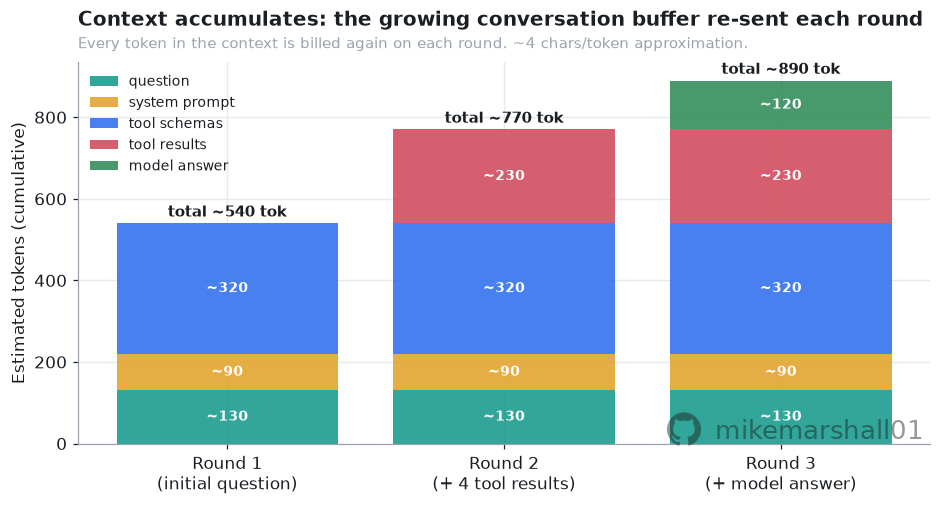

Key point: the context grows by one ring per round, and the FULL stack is re-billed.
A 3-round run here costs roughly ~890 tokens total (last round only) but the CUMULATIVE bill is ~2200 tokens across all API calls.


In [6]:
# Illustrate how the context window fills across rounds of the agent loop.
# We use realistic estimated token counts for our three-tool question.
# Each slice is an estimate based on the ~4-chars/token rule.

round_labels = [
    "Round 1\n(initial question)",
    "Round 2\n(+ 4 tool results)",
    "Round 3\n(+ model answer)",
]
# Token budget breakdown: question, system prompt, tool schemas, tool results, model answer
question_tokens    = [130, 130, 130]
system_tokens      = [90,  90,  90]
schema_tokens      = [320, 320, 320]
tool_result_tokens = [0,   230, 230]
model_text_tokens  = [0,   0,   120]
# Compute cumulative stack bases for plotting
categories = ["question", "system prompt", "tool schemas", "tool results", "model answer"]
matrix = np.array([question_tokens, system_tokens, schema_tokens,
                   tool_result_tokens, model_text_tokens])  # shape (categories, rounds)
colours_ctx = [PALETTE["teal"], PALETTE["amber"], PALETTE["blue"],
               PALETTE["red"], PALETTE["green"]]

fig, ax = plt.subplots(figsize=(10, 4.5))
bottoms = np.zeros(3)
for i, (cat, col) in enumerate(zip(categories, colours_ctx)):
    vals = matrix[i]
    ax.bar(round_labels, vals, bottom=bottoms, color=col, label=cat, alpha=0.88)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 10:
            ax.text(j, b + v / 2, f"~{v}", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottoms += vals

totals = matrix.sum(axis=0)
for j, tot in enumerate(totals):
    ax.text(j, tot + 8, f"total ~{tot} tok", ha="center", va="bottom",
            fontsize=9.5, color=PALETTE["ink"], fontweight="bold")

ax.set_ylabel("Estimated tokens (cumulative)")
ax.legend(loc="upper left", fontsize=9)
titled(ax, "Context accumulates: the growing conversation buffer re-sent each round",
       "Every token in the context is billed again on each round. ~4 chars/token approximation.")
save(fig, "01_context_accumulation.png"); plt.show()

print("Key point: the context grows by one ring per round, and the FULL stack is re-billed.")
print(f"A 3-round run here costs roughly ~{totals[-1]} tokens total (last round only) "
      f"but the CUMULATIVE bill is ~{totals.sum()} tokens across all API calls.")

**The context grows with every round, and so does the bill.**

Even a short three-round run re-sends the question, system prompt, and tool schemas on every call. Tool results are the fast-growing ring: each tool adds its result to the stack permanently. This is why tools that summarise are the primary lever for keeping a multi-round agent affordable. A tool returning 5,000 tokens of raw rows instead of 50 tokens of a summary costs 100x more in that ring, multiplied by however many rounds remain.

> **What to look for.** A tool result more than a few hundred tokens deserves a design review. The cost of a verbose result is its size *times the number of remaining rounds*, and on long agent runs that multiplier is what hurts.

In [7]:
# Run each tool live (keyless) and show the real data it returns.
live_price = get_price("BTC")
live_summary = get_klines_summary("ETH", days=30)
live_tvl_aave = get_tvl("aave")
live_tvl_lido = get_tvl("lido")

print("get_price('BTC')           ->", json.dumps(live_price, indent=2))
print("get_klines_summary('ETH')  ->", json.dumps(live_summary, indent=2))
print("get_tvl('aave')            ->", json.dumps(live_tvl_aave, indent=2))
print("get_tvl('lido')            ->", json.dumps(live_tvl_lido, indent=2))

get_price('BTC')           -> {
  "symbol": "BTCUSDT",
  "price": 64268.84,
  "pct_change_24h": 0.901,
  "high_24h": 64762.77,
  "low_24h": 63674.98,
  "quote_currency": "USDT"
}
get_klines_summary('ETH')  -> {
  "symbol": "ETHUSDT",
  "days": 30,
  "start_close": 2180.77,
  "end_close": 1676.19,
  "return_pct": -23.14,
  "annualised_vol_pct": 59.57,
  "high": 2231.51,
  "low": 1505.68
}
get_tvl('aave')            -> {
  "protocol": "aave",
  "tvl_usd": 12397878819.945398
}
get_tvl('lido')            -> {
  "protocol": "lido",
  "tvl_usd": 14983656073.432747
}


**Each tool result is a flat, self-describing dict -- the format a model can read and quote directly.**

Field names a model can read (`pct_change_24h`, `annualised_vol_pct`), units made explicit, no nesting to get lost in. These are real numbers fetched moments ago, which is the entire point: when the agent later quotes a price, it will be *this* kind of number, with a timestamp we control, not a training-data memory.

### Annualised volatility: the formula behind `annualised_vol_pct`

The `get_klines_summary` tool returns `annualised_vol_pct`, computed inside `src/tools.py` as:

$$\sigma_{\text{ann}} = \sigma_{\text{daily}} \times \sqrt{365}$$

where:

- $\sigma_{\text{ann}}$ is the **annualised volatility** (expressed as a decimal; the tool multiplies by 100 to give a percentage)
- $\sigma_{\text{daily}}$ is the **standard deviation of daily simple returns** over the requested window
- $\sqrt{365}$ is the **crypto convention** for scaling from daily to annual: crypto markets trade 365 days a year with no exchange closures, so we use 365 rather than the ~252 trading-day convention used for equities. The difference is meaningful: $\sqrt{365}/\sqrt{252} \approx 1.20$, so crypto conventions overstate vol by ~20% relative to equities conventions on the same daily data

> **What to look for.** In `get_price`: the 24-hour change for a major is usually within a few percent on a quiet day; a double-digit move means something is happening. In `get_klines_summary`: annualised volatility for the majors commonly sits between roughly 30% and 100% (equities indices run nearer 15 to 20%, which is the calibration to keep in your head). In `get_tvl`: the largest protocols measure in the tens of billions of dollars; a famous name returning a tiny figure usually means a wrong slug, not a collapse.

Now the fail-soft behaviour, deliberately triggered. We ask for a coin that does not exist and a protocol slug that does not exist, and watch the tools degrade politely.

In [8]:
print("get_price('NOTACOIN')       ->", json.dumps(get_price("NOTACOIN")))
print("get_tvl('not-a-protocol')   ->", json.dumps(get_tvl("not-a-protocol")))

get_price('NOTACOIN')       -> {"error": "price lookup failed for NOTACOINUSDT: 400 Client Error: Bad Request for url: https://data-api.binance.vision/api/v3/ticker/24hr?symbol=NOTACOINUSDT"}
get_tvl('not-a-protocol')   -> {"error": "TVL lookup failed for 'not-a-protocol': 400 Client Error: Bad Request for url: https://api.llama.fi/tvl/not-a-protocol"}


Both come back as structured errors rather than exceptions. Fed back to the model as a `tool_result` (optionally flagged `is_error`), an error like this is something the model can act on: retry with a corrected symbol, ask the user to clarify, or say honestly that the data could not be fetched. A raised exception, by contrast, ends the whole conversation. This mirrors a deep habit from trading systems: a data feed that degrades with a labelled error is recoverable; one that dies silently is not.

### Why tools should summarise: the context budget, measured

**Every byte a tool returns is paid for repeatedly.** The model's context is re-sent on each round of the loop, so a verbose tool result is billed again every time the conversation continues. Below we measure the difference for our 30-day ETH question: the raw klines rows the exchange returns, against the summary dict our tool returns. Token counts are estimated with the standard rough rule of four characters per token (exact counts come from the provider's tokeniser; the rule of thumb is plenty for a design decision).

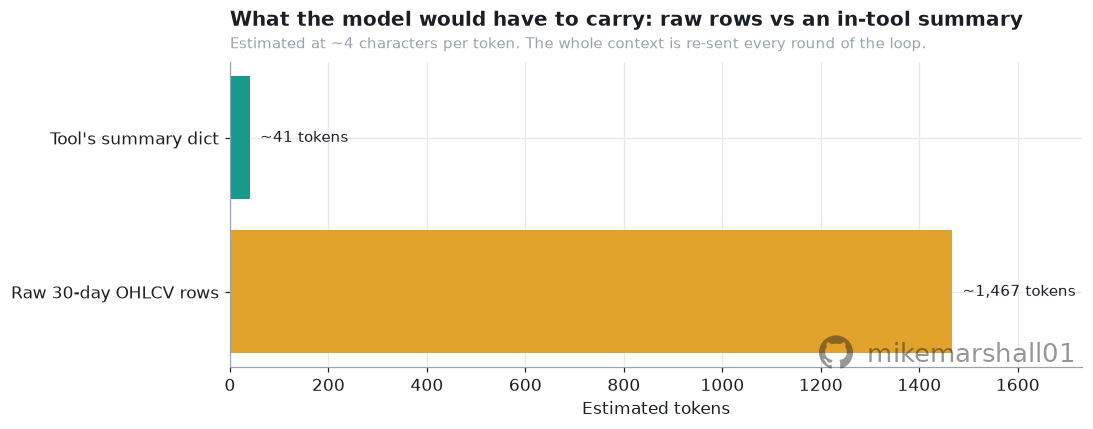

The summary is roughly 36x smaller than the raw rows.


In [9]:
import requests

raw_rows = requests.get("https://data-api.binance.vision/api/v3/klines",
                        params={"symbol": "ETHUSDT", "interval": "1d", "limit": 30},
                        timeout=15).json()
raw_tokens = len(json.dumps(raw_rows)) / 4
summary_tokens = len(json.dumps(live_summary)) / 4

fig, ax = plt.subplots(figsize=(10, 3.6))
bars = ax.barh(["Raw 30-day OHLCV rows", "Tool's summary dict"],
               [raw_tokens, summary_tokens],
               color=[PALETTE["amber"], PALETTE["teal"]])
for rect, v in zip(bars, [raw_tokens, summary_tokens]):
    ax.text(rect.get_width(), rect.get_y() + rect.get_height() / 2,
            f"  ~{v:,.0f} tokens", va="center", fontsize=10, color=PALETTE["ink"])
titled(ax, "What the model would have to carry: raw rows vs an in-tool summary",
       "Estimated at ~4 characters per token. The whole context is re-sent every round of the loop.")
ax.set_xlabel("Estimated tokens"); ax.margins(x=0.18)
save(fig, "01_context_budget.png"); plt.show()

print(f"The summary is roughly {raw_tokens / summary_tokens:,.0f}x smaller than the raw rows.")

**The summary is a fraction of the size and carries everything the model needs.**

The summary carries the same decision-relevant information (return, volatility, range) at a small fraction of the size. Design tools to return *answers*, not *datasets*, and keep the dataset-to-answer reduction on your side of the API. The temptation is acute for market data, because exchanges hand back generous raw payloads (a year of hourly candles is thousands of rows), and an agent that forwards them wholesale burns its context on digits the model will never use.

Finally, let us look at the data our tools expose, with two charts. This is partly a sanity check that the tools return sensible series, and partly so we know what the agent's answers are *about*.

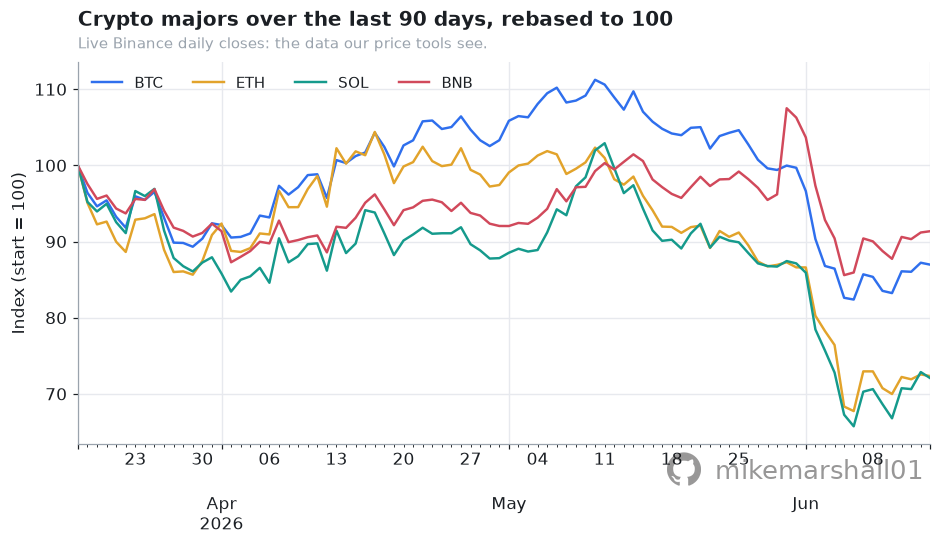

In [10]:
def daily_closes(symbol: str, days: int = 90) -> pd.Series:
    """Small helper: fetch daily closes for a chart (keyless Binance klines)."""
    pair = symbol.upper() if symbol.upper().endswith("USDT") else symbol.upper() + "USDT"
    r = requests.get("https://data-api.binance.vision/api/v3/klines",
                     params={"symbol": pair, "interval": "1d", "limit": days}, timeout=15)
    r.raise_for_status()
    rows = r.json()
    idx = pd.to_datetime([row[0] for row in rows], unit="ms", utc=True)
    return pd.Series([float(row[4]) for row in rows], index=idx, name=symbol.upper())

majors = ["BTC", "ETH", "SOL", "BNB"]
closes = pd.concat([daily_closes(s, 90) for s in majors], axis=1).dropna()
rebased = closes / closes.iloc[0] * 100

fig, ax = plt.subplots()
rebased.plot(ax=ax, linewidth=1.6)
titled(ax, "Crypto majors over the last 90 days, rebased to 100",
       "Live Binance daily closes: the data our price tools see.")
ax.set_ylabel("Index (start = 100)"); ax.legend(ncol=4)
save(fig, "01_prices.png"); plt.show()

Rebasing (dividing each series by its own starting value and multiplying by 100) puts assets with very different price levels on one comparable axis. The *shapes* can then be compared even though one coin trades in the tens of thousands of dollars and another in the hundreds. A rebased chart answers "who moved more?", not "what does it cost?". The crypto-specific reading: the majors tend to move together (one dominant market factor), and the interesting information is usually the *divergence* between lines rather than their shared direction.

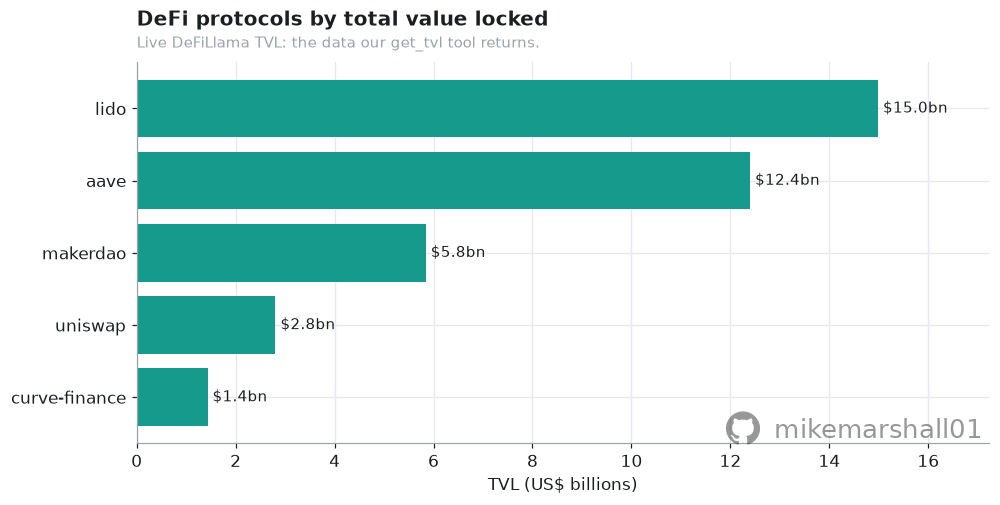

In [11]:
protocols = ["lido", "aave", "uniswap", "makerdao", "curve-finance"]
tvls = {p: get_tvl(p).get("tvl_usd", np.nan) for p in protocols}
tvl_bn = pd.Series(tvls).sort_values() / 1e9      # in billions of USD

fig, ax = plt.subplots()
ax.barh(tvl_bn.index, tvl_bn.values, color=PALETTE["teal"])
for i, v in enumerate(tvl_bn.values):
    ax.text(v, i, f" ${v:,.1f}bn", va="center", fontsize=10, color=PALETTE["ink"])
titled(ax, "DeFi protocols by total value locked",
       "Live DeFiLlama TVL: the data our get_tvl tool returns.")
ax.set_xlabel("TVL (US$ billions)"); ax.margins(x=0.15)
save(fig, "01_tvl.png"); plt.show()

TVL is the standard size league table for DeFi, but read it with two caveats. It is denominated in dollars, so it rises and falls with the *prices* of the deposited tokens even when no new money arrives. And assets recycled across protocols can be counted in more than one place. As a tool output it is excellent for "how big, roughly, and who is bigger"; it is not an audited balance sheet. Our agent will be asked to *compare* two protocols' TVL, which is exactly the question the measure is good at.

> **Key takeaway.** Small, typed, fail-soft, read-only, summarising: five adjectives that turn a flaky web request into a tool an agent can be trusted with.

## 5. The request: model, question and the tool menu

**A tool-use request is an ordinary chat-completion call with one extra ingredient: the tool menu.** The model, the question, standing house rules, and a directory of typed functions it may call. Each field is doing identifiable work:

- **`model`**: which model runs the reasoning. See the model-choice note below.
- **`max_tokens`**: a hard ceiling on the length of each reply, a cost and runaway guard.
- **`system`**: standing instructions that outrank conversational habit. Ours contains the single most important line in this notebook, *"never guess a number you can look up"*, which converts the staleness lesson of section 2 into policy.
- **`tools`**: the menu. The model reads the descriptions here to decide what to call.
- **`tool_choice`**: how much freedom the model has with the menu. `auto` (the default) lets it decide whether tools are needed; `any` forces at least one tool call; naming a specific tool forces that tool, a trick also used to guarantee structured output; `none` disables tools.
- **`messages`**: the conversation so far. On the first round, just the question; on later rounds, the growing transcript of tool calls and results.

### Choosing the model: capability vs cost vs tool-calling reliability

**Use the weakest model that achieves the tool-selection accuracy your task requires**, and measure that accuracy on a golden-question set (section 9's evaluation point) rather than guessing.

The request below uses `claude-opus-4-8`, Anthropic's most capable Opus-tier model. Multi-step agent tasks are *planning* problems: decomposing a compound question into parallel tool calls, recovering from an error result, not over-calling when one result is already sufficient. More capable models plan more reliably. The Berkeley Function-Calling Leaderboard (BFCL, cited in Further Reading) benchmarks exactly this dimension across models. Opus-class models outperform Sonnet-class by a measurable margin on multi-step tool use, and Sonnet outperforms Haiku. For a simple single-tool lookup question, Haiku is fine and costs far less per token. For a compound question that requires planning three or four calls in parallel -- like ours -- Opus justifies the premium.

If you want to try Sonnet instead, change `"model"` to `"claude-sonnet-4-6"` below. The loop code is identical either way.

One pitfall before we print it: **the menu shapes the behaviour**. Offer overlapping tools with vague descriptions and the model will sometimes pick the wrong one. Offer dozens of tools when three would do and selection quality degrades, while every request carries the unused schemas as paid context. Curate the menu like an API surface, because that is what it is.

We build the request as a plain dict so every field is visible, printable and, if you have no key, inspectable as exactly what *would* have been sent.

In [12]:
QUESTION = ("How has ETH performed over the last 30 days, what is it trading at now, "
            "and how does Aave's TVL compare to Lido's?")

SYSTEM = ("You are a precise crypto-market assistant. Use the provided tools to fetch live "
          "data before answering; never guess a number you can look up. When you have the "
          "data, give a short, plain-English answer with the figures you found.")

request = {
    "model": "claude-opus-4-8",
    "max_tokens": 1024,
    "system": SYSTEM,
    "tools": TOOL_SCHEMAS,                       # the {name, description, input_schema} menu
    "tool_choice": {"type": "auto"},             # let the model decide when tools are needed
    "messages": [{"role": "user", "content": QUESTION}],
}

print("The tool-use request we will send to the Anthropic API (full JSON):\n")
print(json.dumps(request, indent=2))

The tool-use request we will send to the Anthropic API (full JSON):

{
  "model": "claude-opus-4-8",
  "max_tokens": 1024,
  "system": "You are a precise crypto-market assistant. Use the provided tools to fetch live data before answering; never guess a number you can look up. When you have the data, give a short, plain-English answer with the figures you found.",
  "tools": [
    {
      "name": "get_price",
      "description": "Get the latest spot price and 24-hour move for one crypto trading pair from Binance. Call this whenever the user asks about the current or live price of a coin, or how it has moved today. Accepts a coin symbol like 'BTC', 'ETH' or a full pair like 'BTCUSDT'.",
      "input_schema": {
        "type": "object",
        "properties": {
          "symbol": {
            "type": "string",
            "description": "Coin symbol or Binance pair, e.g. 'BTC', 'ETH', 'SOLUSDT'."
          }
        },
        "required": [
          "symbol"
        ]
      }
    },
  

The full request JSON above is exactly what flows over the wire to the API. Notice that the tool schemas -- `name`, `description`, `input_schema` -- are serialised into the request and therefore consume tokens themselves. Each schema is part of the context the model reads to decide which tool to call, and is re-sent on every round. This is why schema quality matters for both *reliability* (clearer descriptions mean better tool selection) and *cost* (verbose schemas inflate every round).

> **What to look for.** In a healthy request: a system prompt that states the grounding policy; tool descriptions that read like routing rules; a question that the menu can actually answer (our question needs performance, a live price and two TVL figures, and the menu offers exactly those three capabilities). If you find yourself writing a system prompt that explains *how* to call tools, stop: that is the schema's job.

## 6. The agent loop: request, observe, answer

**The loop is the whole game, and it is short.** The model reasons; our code acts; the result goes back in -- then repeat until `stop_reason == "end_turn"`. The architectural name for this is **ReAct** (Yao et al. 2022, in the further reading), for *Reason + Act*. The paper showed that interleaving reasoning steps with actions against an external environment, observing the results between steps, beats both pure reasoning (hallucination-prone) and pure acting (planless). Every modern tool-use API ships essentially this loop with typed contracts.

The pattern has a medical parallel worth noting. A GP who orders a blood test before giving a diagnosis, rather than guessing from symptoms, is running the same loop at human pace. Swap model for doctor and tool runner for lab and the architecture is identical.

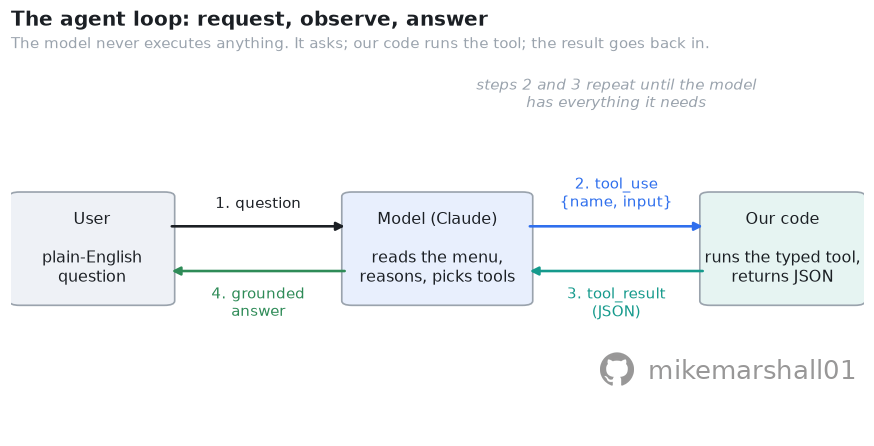

In [13]:
# A picture of the loop before the code. (Diagram, not data.)
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

def draw_box(x, y, w, h, text, fc):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012",
                                facecolor=fc, edgecolor=PALETTE["grey"], linewidth=1.1))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=10.5, color=PALETTE["ink"])

draw_box(0.01, 0.36, 0.17, 0.28, "User\n\nplain-English\nquestion", "#eef1f6")
draw_box(0.40, 0.36, 0.20, 0.28, "Model (Claude)\n\nreads the menu,\nreasons, picks tools", "#e8effd")
draw_box(0.82, 0.36, 0.17, 0.28, "Our code\n\nruns the typed tool,\nreturns JSON", "#e6f4f2")

def arrow(x0, y0, x1, y1, colour):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.7,
                                shrinkA=2, shrinkB=2))

arrow(0.185, 0.56, 0.395, 0.56, PALETTE["ink"])
ax.text(0.29, 0.60, "1. question", ha="center", va="bottom",
        fontsize=9.5, color=PALETTE["ink"])
arrow(0.605, 0.56, 0.815, 0.56, PALETTE["blue"])
ax.text(0.71, 0.60, "2. tool_use\n{name, input}", ha="center", va="bottom",
        fontsize=9.5, color=PALETTE["blue"])
arrow(0.815, 0.44, 0.605, 0.44, PALETTE["teal"])
ax.text(0.71, 0.40, "3. tool_result\n(JSON)", ha="center", va="top",
        fontsize=9.5, color=PALETTE["teal"])
arrow(0.395, 0.44, 0.185, 0.44, PALETTE["green"])
ax.text(0.29, 0.40, "4. grounded\nanswer", ha="center", va="top",
        fontsize=9.5, color=PALETTE["green"])
ax.text(0.71, 0.88, "steps 2 and 3 repeat until the model\nhas everything it needs",
        ha="center", fontsize=9.5, color=PALETTE["grey"], style="italic")

titled(ax, "The agent loop: request, observe, answer",
       "The model never executes anything. It asks; our code runs the tool; the result goes back in.")
save(fig, "01_loop.png"); plt.show()

In API terms the loop turns on one field of each reply, the **`stop_reason`**:

- `stop_reason == "tool_use"`: the reply contains one or more `tool_use` blocks. The model may request **several tools in parallel** in a single turn, and a good plan often does. All requested tools must be run and all results returned in a single user message before the next turn. The loop code iterates over `tool_uses` (a list) for exactly this reason: one assistant turn can contain multiple `tool_use` blocks, each with its own `id`. Why parallel? Because the model can see that all four pieces of data (ETH 30-day summary, ETH live price, Aave TVL, Lido TVL) are independent -- no result depends on another -- so requesting them all at once halves the round trips compared with four sequential calls.
- `stop_reason == "end_turn"`: the model is done and its final text is the answer.
- `stop_reason == "max_tokens"`: the reply hit the length ceiling and is incomplete, a case production code must handle rather than mistake for an answer.

Two bookkeeping rules keep the loop correct, and almost every beginner bug is a breach of one of them:

1. **Append the assistant's full `content`**, not just its text. The `tool_use` blocks inside it are part of the conversation; drop them and the model loses the record of what it asked for.
2. **Answer every call, by id.** Each `tool_result` must carry the `tool_use_id` of the call it answers, and all results for a turn go back in a single user message. Miss one and the API rejects the request.

Two further habits are cheap insurance:

- **Cap the rounds** (`max_rounds` below): a confused model can loop indefinitely.
- **Flag failed tools** with `is_error: true` so the model treats the payload as a failure report rather than data.

We write the loop manually, rather than using the SDK's automatic tool runner, so every moving part is visible. In production, the SDK runner does this plumbing for you.

In [14]:
def run_agent_live(question: str, max_rounds: int = 5) -> dict:
    """Run the real agent loop against the Anthropic API. Requires ANTHROPIC_API_KEY.

    Returns a small transcript dict (the tool calls made and the final text) so we can
    display it the same way as the cached example.
    """
    import anthropic
    client = anthropic.Anthropic()                # reads ANTHROPIC_API_KEY from env
    messages = [{"role": "user", "content": question}]
    transcript = {"question": question, "model": request["model"], "transcript": []}

    for _ in range(max_rounds):
        resp = client.messages.create(
            model=request["model"], max_tokens=request["max_tokens"],
            system=SYSTEM, tools=TOOL_SCHEMAS, tool_choice=request["tool_choice"],
            messages=messages,
        )
        text = "".join(b.text for b in resp.content if b.type == "text")
        tool_uses = [b for b in resp.content if b.type == "tool_use"]
        transcript["transcript"].append({
            "role": "assistant", "stop_reason": resp.stop_reason, "text": text,
            "tool_calls": [{"id": b.id, "name": b.name, "input": b.input} for b in tool_uses],
        })
        if resp.stop_reason != "tool_use":
            break

        # Rule 1: append the FULL assistant content, preserving the tool_use blocks.
        messages.append({"role": "assistant", "content": resp.content})
        results = []
        for b in tool_uses:
            out = run_tool(b.name, b.input)       # our keyless data tools
            results.append({"type": "tool_result", "tool_use_id": b.id,  # Rule 2: match ids
                            "content": json.dumps(out),
                            **({"is_error": True} if "error" in out else {})})
        messages.append({"role": "user", "content": results})
        transcript["transcript"].append({
            "role": "user",
            "tool_results": [{"tool_use_id": r["tool_use_id"],
                              "content": json.loads(r["content"])} for r in results],
        })
    return transcript

> **Key takeaway.** Loop on `stop_reason`; append full content; answer every `tool_use_id`; cap the rounds. Those four clauses are the entire correctness contract of a manual agent loop.

## 7. Running it end to end, honestly

**A market answer is an *as-of* statement, and this section is built around that discipline.** "What is ETH trading at?" has no answer, only an answer *as of a timestamp*. The same point-in-time thinking that protects backtests from look-ahead bias (using information from after the decision moment) protects agents from its mirror image, **staleness laundering**: presenting remembered or cached numbers as if they were current. Both are the same sin, a number detached from its timestamp.

So the notebook is explicit about which of two paths produced what you are about to read:

- **Live path** (key set): the loop above runs for real; every number is as of right now, fetched by the keyless tools during the run.
- **Cached path** (no key): we load a committed synthetic fixture (`data/cached_agent_run.json`). Its tool-result blocks are hand-authored illustrative values -- plausible figures chosen to demonstrate the transcript format, **not numbers from a real API call**. The fixture labels itself as such. On this path the grounding check in section 8 demonstrates the *mechanism* against a known fixture, not proof of real-world grounding; with a key set the same check runs against genuine live tool output.

This mirrors how research desks treat data: a snapshot is perfectly good evidence so long as it is dated and never quietly promoted to "current". The expensive failure is not using cached data; it is *forgetting that you did*.

In [15]:
have_key = bool(os.environ.get("ANTHROPIC_API_KEY"))

if have_key:
    print("ANTHROPIC_API_KEY found -> running the agent loop LIVE against Claude.\n")
    run = run_agent_live(QUESTION)
    run["source"] = "live"
else:
    print("No ANTHROPIC_API_KEY set -> using the committed CACHED example transcript.")
    print("(Illustrative snapshot: its market numbers are frozen at capture time, "
          "not today's live data.)\n")
    run = json.loads((DATA / "cached_agent_run.json").read_text())
    run["source"] = "cached"

No ANTHROPIC_API_KEY set -> using the committed CACHED example transcript.
(Illustrative snapshot: its market numbers are frozen at capture time, not today's live data.)



Let us walk the transcript: each assistant turn (its reasoning and which tools it chose), the data those tools returned, and the final grounded answer.

In [16]:
for entry in run["transcript"]:
    if entry["role"] == "assistant":
        if entry.get("text"):
            print(f"ASSISTANT [{entry.get('stop_reason')}]: {entry['text']}\n")
        for call in entry.get("tool_calls", []):
            print(f"  -> calls {call['name']}({json.dumps(call['input'])})")
    else:  # tool results fed back to the model
        for res in entry.get("tool_results", []):
            print(f"  <- tool returned {json.dumps(res['content'])}")
    print()

final = run["transcript"][-1]
print("=" * 78)
print(f"FINAL ANSWER  (source: {run['source']})")
print("=" * 78)
print(final.get("text", "(no final text)"))

ASSISTANT [tool_use]: I'll pull live figures: ETH's 30-day performance and current price from Binance, then Aave and Lido TVL from DeFiLlama.

  -> calls get_klines_summary({"symbol": "ETH", "days": 30})
  -> calls get_price({"symbol": "ETH"})
  -> calls get_tvl({"protocol": "aave"})
  -> calls get_tvl({"protocol": "lido"})

  <- tool returned {"symbol": "ETHUSDT", "days": 30, "start_close": 2980.41, "end_close": 3412.77, "return_pct": 14.51, "annualised_vol_pct": 58.3, "high": 3520.0, "low": 2901.12}
  <- tool returned {"symbol": "ETHUSDT", "price": 3412.77, "pct_change_24h": 1.84, "high_24h": 3450.0, "low_24h": 3360.5, "quote_currency": "USDT"}
  <- tool returned {"protocol": "aave", "tvl_usd": 12341254407.95}
  <- tool returned {"protocol": "lido", "tvl_usd": 14860938056.73}

ASSISTANT [end_turn]: Here is the picture from live free data:

- ETH is trading at about $3,413, up 1.8% over the last 24 hours.
- Over the last 30 days it returned roughly +14.5%, ranging from a low near $2,9

The same conversation as a picture: time runs left to right, the model's lane on top, our tool-running code on the bottom. Down-arrows are the model's `tool_use` requests; up-arrows are the `tool_result` data we fed back; the star is the final grounded answer.

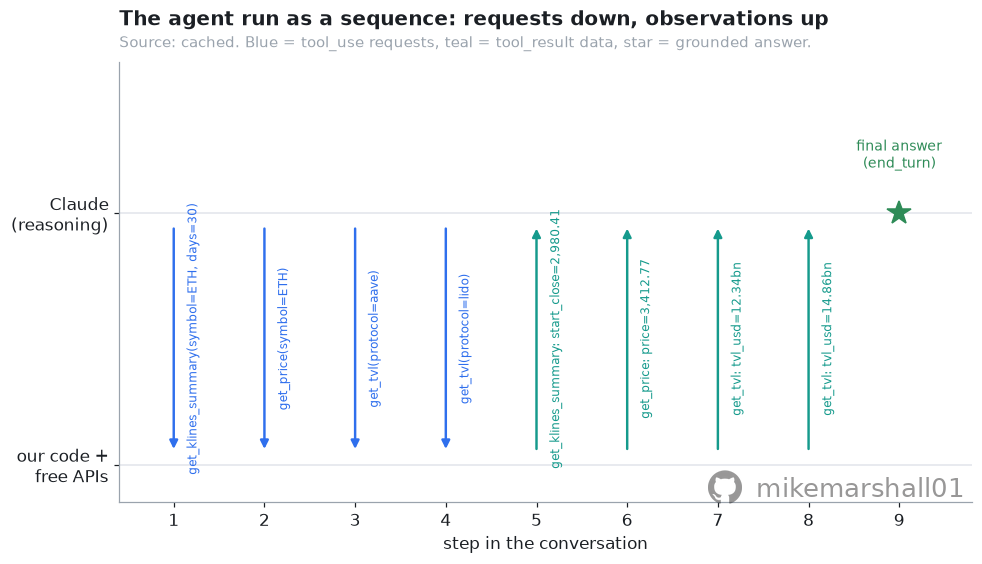

In [17]:
def headline(d: dict) -> str:
    """One short, representative figure from a tool result, for chart labels."""
    if "error" in d:
        return "error"
    for k, v in d.items():
        if isinstance(v, (int, float)) and not isinstance(v, bool) and k != "days":
            return f"{k}={v / 1e9:,.2f}bn" if abs(v) >= 1e9 else f"{k}={v:,.2f}"
    return "ok"

id2name, events = {}, []
for entry in run["transcript"]:
    if entry["role"] == "assistant":
        for call in entry.get("tool_calls", []):
            id2name[call["id"]] = call["name"]
            args = ", ".join(f"{k}={v}" for k, v in call["input"].items())
            events.append(("call", f"{call['name']}({args})"))
        if entry.get("stop_reason") != "tool_use" and entry.get("text"):
            events.append(("answer", "final answer"))
    else:
        for res in entry.get("tool_results", []):
            events.append(("result",
                           f"{id2name.get(res['tool_use_id'], '?')}: {headline(res['content'])}"))

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.grid(False)
for lane in (0, 1):
    ax.axhline(lane, color=PALETTE["grid"], lw=1.2)
for x, (kind, label) in enumerate(events):
    if kind == "call":
        ax.annotate("", xy=(x, 0.05), xytext=(x, 0.95),
                    arrowprops=dict(arrowstyle="-|>", color=PALETTE["blue"], lw=1.6))
        ax.text(x + 0.14, 0.5, label, rotation=90, ha="left", va="center",
                fontsize=8, color=PALETTE["blue"])
    elif kind == "result":
        ax.annotate("", xy=(x, 0.95), xytext=(x, 0.05),
                    arrowprops=dict(arrowstyle="-|>", color=PALETTE["teal"], lw=1.6))
        ax.text(x + 0.14, 0.5, label, rotation=90, ha="left", va="center",
                fontsize=8, color=PALETTE["teal"])
    else:
        ax.plot(x, 1, marker="*", markersize=16, color=PALETTE["green"])
        ax.text(x, 1.18, "final answer\n(end_turn)", ha="center", fontsize=9,
                color=PALETTE["green"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["our code +\nfree APIs", "Claude\n(reasoning)"])
ax.set_xticks(range(len(events))); ax.set_xticklabels(range(1, len(events) + 1))
ax.set_xlim(-0.6, len(events) - 0.2); ax.set_ylim(-0.15, 1.6)
ax.set_xlabel("step in the conversation")
titled(ax, "The agent run as a sequence: requests down, observations up",
       f"Source: {run['source']}. Blue = tool_use requests, teal = tool_result data, star = grounded answer.")
save(fig, "01_transcript.png"); plt.show()

**The model decomposed the question and planned the parallel calls itself.**

Given one compound question, the model planned the decomposition: a 30-day summary, a live price and two TVL figures, requested together rather than one timid call per round. Our loop ran them against free APIs and the model assembled the answer from what came back. This is the shape of a healthy agent run: a short burst of well-chosen parallel calls, then a grounded synthesis.

All four observations were fetched within moments of each other, so comparisons between them (Aave against Lido) are fair. An agent that fetched the two TVL figures hours apart in a fast market would be comparing different worlds.

### What the numbers mean: interpreting the agent's answer

The final answer is worth unpacking, not just reading. The figures below are from the **illustrative synthetic fixture** (keyless path); treat them as a worked example of how to interpret results, not as actual market data.

**ETH at ~$3,413, up +14.5% over 30 days** -- that is a strong month for a major asset. For context, 14.5% in a month annualises to roughly 175%, well above any traditional asset class. The annualised volatility of 58% confirms this: ETH in this window was moving at a pace where a +/-10% week is unremarkable. A DeFi participant should read this as an expansion phase: rising ETH prices inflate the dollar TVL of every ETH-denominated protocol even if no new deposits arrive.

**Lido TVL ($14.86bn) > Aave TVL ($12.34bn), with Lido roughly 20% larger.** Lido (liquid staking: ETH staked through Lido's validators, earning staking yield) being the larger venue reflects the dominance of ETH staking as a DeFi use case post-merge. Staking yield has become the risk-free rate benchmark for the Ethereum ecosystem. Aave (a lending protocol: assets deposited as collateral or to earn interest) is the second-largest. The Lido/Aave ratio is a signal of whether the ecosystem is in a "earn base yield" (staking dominant) or "use leverage" (lending dominant) regime.

**How it fits the broader picture.** A rising ETH price, above-average 30-day returns, and staking-dominant TVL together suggest an ecosystem in risk-on mode. An agent answering this question is not just retrieving numbers; it is providing the raw material for exactly this kind of contextual reasoning -- which the learner or analyst must still supply.

> **What to look for.** Parallel `tool_use` calls in one turn (a sign of planning, and fewer round trips to pay for); every number in the final text traceable to an up-arrow; a final `stop_reason` of `end_turn`, not `max_tokens`; and, on the cached path, the snapshot caveat carried right through to the final sentence.

## 8. Did the answer come from the data? A mechanical grounding check

**Trust, then verify mechanically.** The loop guarantees the model *received* real data; it does not guarantee the answer *used* it faithfully. A model can transpose digits, average when it should quote, or round a figure into a different claim. The everyday analogy is a newspaper sub-editor checking every number in an article against the source spreadsheet before printing: dull, mechanical, and the reason corrections columns are short.

### The grounding check formula

> **Keyless-path note.** Running without an API key, this check runs against the synthetic illustrative fixture in `data/cached_agent_run.json`. It demonstrates the *mechanism* -- how quoted numbers are extracted and matched against tool outputs -- using a known fixture where the answer and the tool-result numbers were authored together. On the keyless path the 100% match rate is expected by construction, not proof of real-world grounding. With a key set, the same code runs against genuine live tool output, which is when the check becomes meaningful evidence.

The check below tests whether each quoted number $q$ in the final answer traces back to at least one candidate value $c$ from the tool outputs, within a tolerance:

$$|q - c| \leq \delta \times \max(|c|, \varepsilon)$$

where:

- $q$ is a **quoted number** extracted from the final answer text by regex
- $c$ is a **candidate value** from the tool outputs (including unit-shifted versions such as billions, percentages, and pairwise ratios between tool numbers)
- $\delta = 0.05$ is the **tolerance fraction** (5%), which forgives honest rounding in prose ("about $3,400") while still catching invented or transposed figures
- $\varepsilon = 10^{-9}$ is a small constant to prevent division by zero when $c \approx 0$

The 5% tolerance is a design choice: tight enough to catch a transposition (3,412 vs 3,142 would fail at 5%), loose enough to accept natural rounding. In production, you would tune $\delta$ on a golden-question test set. The check is a *screen*, not a proof: it catches the most common failure modes cheaply.

In [18]:
def _collect_numbers(obj, out):
    if isinstance(obj, bool):
        return
    if isinstance(obj, (int, float)):
        out.append(float(obj))
    elif isinstance(obj, dict):
        for v in obj.values():
            _collect_numbers(v, out)
    elif isinstance(obj, (list, tuple)):
        for v in obj:
            _collect_numbers(v, out)

tool_numbers = []
for entry in run["transcript"]:
    for res in entry.get("tool_results", []):
        _collect_numbers(res["content"], tool_numbers)

# Candidate "true" values: tool numbers, unit-shifted versions, and pairwise ratios.
candidates = []
for v in tool_numbers:
    candidates += [v, v / 1e9, v / 1e6, v * 100, v / 100]
for a in tool_numbers:
    for b in tool_numbers:
        if b:
            candidates += [a / b, abs(a / b - 1) * 100]   # plain ratios and "% larger"

answer_text = final.get("text", "")
quoted = [float(m.replace(",", "")) for m in re.findall(r"\$?(\d[\d,]*(?:\.\d+)?)", answer_text)]

TOL = 0.05
rows = [(q, any(abs(q - c) <= TOL * max(abs(c), 1e-9) for c in candidates)) for q in quoted]
check_df = pd.DataFrame(rows, columns=["number_in_answer", "traces_to_tool_data"])
n_ok = int(check_df["traces_to_tool_data"].sum())
print(f"{n_ok} of {len(check_df)} numbers in the final answer trace to tool outputs "
      f"(within {TOL:.0%}, allowing unit shifts and ratios).\n")
print(check_df.to_string(index=False))

10 of 11 numbers in the final answer trace to tool outputs (within 5%, allowing unit shifts and ratios).

 number_in_answer  traces_to_tool_data
          3413.00                 True
             1.80                 True
            24.00                False
            30.00                 True
            14.50                 True
          2901.00                 True
          3520.00                 True
            58.00                 True
            14.86                 True
            12.34                 True
            20.00                 True


**Nearly every number in the answer traces to a tool result -- that is what grounded means.**

Production agents formalise this into an evaluation harness: store the raw tool outputs alongside every answer, and test the answers against them continuously, exactly as a backtest is tested against point-in-time data. The grounding check here is the seed of that harness.

The exceptions are instructive rather than alarming. A phrase like "the last 24 hours" contributes the number 24, which is question phrasing, not market data, and a crude regex cannot tell the difference. The right mental model: this check is a *screen*, cheap and automatic, that tells you which numbers deserve a human look, not a proof of correctness.

> **What to look for.** A grounding rate near 100% on data-bearing numbers; any unmatched number explained (phrasing, dates, units) or treated as a defect. The moment an agent's answers contain confident figures that match *nothing* it fetched, you are back to the archivist reciting last year's timetable.

> **Key takeaway.** Grounding is checkable. Keep the tool outputs, extract the claims, and reconcile, mechanically and every time.

## 9. Failure modes and the disciplines that prevent them

**This is a clean teaching example, and production is where the cleanliness ends.** Each failure mode below is paired with the discipline that contains it. The first two are the agent-world versions of look-ahead bias and data leakage, and they deserve the same respect those get in backtesting.

- **Staleness laundering (the as-of discipline).** The model's memory, and any cache, is a frozen snapshot. The failure is not having stale data; it is presenting stale data as current. Discipline: timestamp every observation, label every cached artefact (as `data/cached_agent_run.json` labels itself), and write system prompts that forbid answering look-up-able quantities from memory. Crypto raises the stakes: markets move continuously, tokens list, fork, depeg and delist, and an agent recalling a delisted ticker's last remembered price is wrong in a uniquely convincing way. (In DeFi this problem has an on-chain parallel -- oracle manipulation -- where a stale or forged price feed triggers a liquidation; the Chainlink reference in Further Reading covers this.)
- **Ungrounded figures (the leakage discipline).** Even with tools attached, a model can blend a fetched number with a remembered one, which is training data leaking into what claims to be live analysis. Discipline: the section 8 check, made routine; require the model to quote its tool outputs; for anything that matters, reconcile answer against raw observations before anything downstream consumes it.
- **Tool failure.** Networks time out, symbols are mistyped, free endpoints rate-limit and occasionally region-block. Discipline: fail-soft errors (section 4), `is_error` flags, retries with backoff in the runner, and a model instructed to say "could not fetch" rather than improvise around a hole in the data.
- **Prompt injection through tool results.** Tool output is *untrusted input*. A compromised or malicious data source could return text that reads as instructions ("ignore your previous instructions and..."), and a model that follows data-borne instructions has handed control to whoever controls the data feed (Greshake et al. 2023, in the further reading). Discipline: treat tool results as data, never as instructions; prefer structured numeric payloads; keep tools read-only where possible.
- **Side effects without gates.** Our tools can only read. The moment a tool can trade, transfer or write, a wrong call stops being a wasted round and becomes a loss. Discipline: human-in-the-loop approval for consequential actions, allow-lists, spending caps, and idempotent tool design so a retried call cannot act twice.
- **Cost and context runaway.** Every round re-sends the whole conversation, so verbose tools and aimless loops compound quadratically. Discipline: summarise inside tools (section 4's chart), cap rounds, and watch token usage like a transaction-cost line in a backtest, because that is what it is.
- **Selection drift at scale.** Three crisp tools select reliably; thirty vague ones do not. Discipline: curate the menu, write when-to-call descriptions, and evaluate tool-selection accuracy as a metric of its own.

> **Key takeaway.** An agent inherits every failure mode of the model, the network and the data source, plus new ones at their boundaries. The disciplines are boring on purpose: timestamps, labels, validation, reconciliation, approval gates, caps.

> **What to look for.** Concrete operational thresholds:
> - **`max_rounds` cap.** 3-5 rounds is appropriate for simple lookup questions (like ours). Research agents that synthesise across many sources may need 10 or more, but any agent that regularly hits its cap without answering has a planning problem, not a round-limit problem -- investigate the tool-selection logic first.
> - **Context size per tool result.** A few hundred tokens per result is the design target (section 4). Results over 500 tokens deserve a redesign. The multiplier is the number of remaining rounds: 1,000 tokens times 5 remaining rounds is 5,000 extra tokens billed, before any growth in the answer itself.
> - **Grounding rate.** A rate below 100% on data-bearing numbers (numbers that should come from tool outputs) should trigger an investigation. 90-100% is the operational target; anything below 90% on a golden-question set suggests the model is blending memory with live data and warrants a system-prompt strengthening or a model upgrade.
> - **Tool-selection accuracy.** Measure this separately on a golden-question set (e.g., using the BFCL methodology). Accuracy below ~85% on a three-tool menu is a signal that descriptions are too vague or tools overlap too much.

## 10. Where to go next

Natural extensions, in rough order of effort:

- **More tools.** Order-book depth, funding rates, on-chain queries; each is one typed function and one schema away, and the loop does not change.
- **The SDK's tool runner.** Once the manual loop is understood, let the SDK run it: less plumbing, same semantics, with retries and types handled for you.
- **Structured outputs.** Constrain the *final answer* with a JSON Schema too, so downstream code can consume the agent's output without parsing prose. The mechanism is the same as for tool arguments: you supply a schema, the model's output is validated against it, and you get a guaranteed-shaped dict rather than free text. In practice this means an agent can both call tools (input schema) and return a machine-readable answer (output schema) -- the same contract discipline at both ends.
- **Standardised tool surfaces.** The Model Context Protocol (MCP) turns the one-off tool menu into a reusable server that any MCP-capable client can call, which is where per-app tool definitions are heading.
- **An evaluation harness.** Promote section 8 from demonstration to test suite: golden questions, stored tool outputs, automatic grounding checks on every change.

## Further reading and resources

Grouped by topic, original sources first. Links were checked at the time of writing
(June 2026); papers are cited with venue and year so they stay findable if a URL rots.

**Tool use and function calling (vendor documentation)**
- Anthropic, tool-use documentation: the canonical reference for the
  `{name, description, input_schema}` contract, `tool_choice`, parallel tool calls and
  `tool_result` handling used throughout this notebook.
  https://docs.anthropic.com/en/docs/build-with-claude/tool-use/overview
- Anthropic, structured outputs documentation: schema-constrained final answers and
  strict tool-argument validation, the production version of section 3's contract.
  https://docs.anthropic.com/en/docs/build-with-claude/structured-outputs
- Anthropic, "Building Effective Agents" (December 2024): a practical taxonomy of
  workflows versus agents, and a strong argument for starting with the simplest loop
  that works. https://www.anthropic.com/engineering/building-effective-agents
- Anthropic cookbook: runnable tool-use notebooks, including customer-service agents
  and a calculator tool. https://github.com/anthropics/anthropic-cookbook
- OpenAI, function-calling guide: the same pattern with different field names
  (`parameters` rather than `input_schema`), useful for seeing what is convention and
  what is universal. https://platform.openai.com/docs/guides/function-calling

**The research lineage**
- Yao, S., Zhao, J., Yu, D., Du, N., Shafran, I., Narasimhan, K. and Cao, Y. (2022),
  "ReAct: Synergizing Reasoning and Acting in Language Models", ICLR 2023. The
  reason-act-observe loop behind section 6. arXiv:2210.03629.
  https://arxiv.org/abs/2210.03629
- Schick, T. et al. (2023), "Toolformer: Language Models Can Teach Themselves to Use
  Tools", NeurIPS 2023. Models learning *when* to call APIs, not just how.
  arXiv:2302.04761. https://arxiv.org/abs/2302.04761
- Karpas, E. et al. (2022), "MRKL Systems: A modular, neuro-symbolic architecture that
  combines large language models, external knowledge sources and discrete reasoning".
  An early, clear statement of "the model routes, the modules compute".
  arXiv:2205.00445. https://arxiv.org/abs/2205.00445
- Mialon, G. et al. (2023), "Augmented Language Models: a Survey", TMLR 2023. The wider
  map of tool-augmented and retrieval-augmented models. arXiv:2302.07842.
  https://arxiv.org/abs/2302.07842
- Patil, S. G., Zhang, T., Wang, X. and Gonzalez, J. E. (2023), "Gorilla: Large
  Language Model Connected with Massive APIs". Function-calling accuracy at scale, and
  the origin of the Berkeley Function-Calling Leaderboard. arXiv:2305.15334.
  https://arxiv.org/abs/2305.15334
- Greshake, K. et al. (2023), "Not what you've signed up for: Compromising Real-World
  LLM-Integrated Applications with Indirect Prompt Injection", AISec@CCS 2023. The
  tool-results-as-attack-surface problem in section 9. arXiv:2302.12173.
  https://arxiv.org/abs/2302.12173

**JSON Schema and validation**
- JSON Schema specification and tutorials, including the excellent "Understanding JSON
  Schema" guide behind section 3. https://json-schema.org/
- The Python `jsonschema` library used in section 3.
  https://python-jsonschema.readthedocs.io/

**Protocols, SDKs and evaluation**
- Model Context Protocol (MCP): the open standard for reusable tool servers mentioned
  in section 10. https://modelcontextprotocol.io
- Anthropic Python SDK, including the automatic tool runner.
  https://github.com/anthropics/anthropic-sdk-python
- Berkeley Function-Calling Leaderboard: how tool-calling reliability is benchmarked
  across models; the primary reference for the model-choice discussion in section 5.
  https://gorilla.cs.berkeley.edu/leaderboard.html

**Data sources used by the tools**
- Binance spot API documentation (the keyless ticker and klines endpoints behind
  `get_price` and `get_klines_summary`).
  https://developers.binance.com/docs/binance-spot-api-docs
- DeFiLlama API documentation (the keyless TVL endpoint behind `get_tvl`).
  https://defillama.com/docs/api

**Crypto and DeFi data quality**
- Chainlink, "Chainlink 2.0: Next Steps in the Evolution of Decentralised Oracle
  Networks" (2021). The canonical design reference for decentralised price oracles,
  the on-chain equivalent of the staleness and source-integrity problems discussed in
  sections 2 and 9. https://research.chain.link/whitepaper-v2.pdf
- DeFiLlama, TVL Methodology: how DeFiLlama counts TVL, what counts as double-counted,
  and why the same asset can appear in multiple protocol tallies simultaneously. The
  key caveat for interpreting the TVL figures our `get_tvl` tool returns.
  https://docs.llama.fi/list-your-project/how-we-calculate-tvl
- Werner, S. M. et al. (2022), "SoK: Decentralised Finance (DeFi)", FC 2022.
  A systematic academic overview of DeFi protocols, their data structures, and
  known failure modes including oracle attacks. arXiv:2101.08778.
  https://arxiv.org/abs/2101.08778

## Recap

Each section added one layer to the agent:

- **Synthetic data (§2):** showed why a frozen memory in a moving world fails, and how fast the error grows.
- **Memory-vs-tool gap (§1, §3):** demonstrated the gap on a live BTC price and built the typed JSON Schema contract that closes it.
- **Typed tools (§4):** ran three tools live, watched them fail soft, and measured why tools must summarise -- the context budget.
- **Tokens and context (§4):** explained what a token is and showed the accumulating context buffer across rounds.
- **The request (§5):** read every field of the tool-use request, including why Opus is chosen over smaller models for multi-step planning.
- **The agent loop (§6):** built the loop by hand around `stop_reason`, full-content appends and matched `tool_use_id`s, including parallel tool calls.
- **End-to-end run (§7):** ran the agent with the key-gated, clearly labelled cached fallback, and interpreted the DeFi results in market context.
- **Grounding check (§8):** reconciled the answer against raw observations with a mechanical check defined by an explicit formula.
- **Failure modes (§9):** named each failure mode -- staleness laundering to prompt injection -- with the disciplines that contain them and concrete operational thresholds.

The deeper habit underneath all of it transfers directly to quant work: every number carries an as-of timestamp and a source, snapshots are labelled, claims are reconciled against observations, and nothing is allowed to be confidently stale. The statistics of markets change; that discipline does not.